# Fake News Classification
Professional end-to-end NLP workflow for fake news detection using multiple machine learning models.

## Notebook Overview
This notebook covers dataset acquisition, exploratory data analysis (EDA), preprocessing, feature extraction, model training, evaluation, and sample prediction for fake news classification.

## Professor Pipeline Alignment
This notebook is organized to follow the requested workflow from the provided pipeline diagrams.

| Stage | Pipeline Step | Notebook Implementation |
| --- | --- | --- |
| 01 | Problem + Dataset | Dataset acquisition, loading, and label creation |
| 02 | Data Understanding | Dataset information, summaries, and EDA |
| 03 | Data Cleaning | Missing-value handling, duplicate removal, and raw-text assembly |
| 04 | Text Preprocessing | Text normalization, cleaning, tokenization, stopword removal, POS-aware lemmatization |
| 05 | Data Split | Stratified train/test split |
| 06 | Word Embedding / Word Vectors | TF-IDF document vectors for classical ML |
| 07 | ML Algorithm Building | Baseline Logistic Regression, Naive Bayes, Linear SVM, and Random Forest |
| 08 | Hyperparameter Tuning | GridSearchCV and RandomizedSearchCV refinement on shortlisted baseline models |
| 09 | Tuned Model | Best tuned candidate selected using cross-validated F1 |
| 10 | Evaluation | Test-set metrics, confusion matrix, ROC, PR curve, and comparison plots |
| 11 | Prediction | End-to-end sample inference using the final preprocessing pipeline |

For this classical machine-learning workflow, the professor's word embedding stage is implemented as TF-IDF vectorization, which converts each preprocessed article into a sparse numerical feature vector.

## Import Required Packages

In [ ]:

# Core data handling and computation
import os  # Operating system utilities
import pickle  # Persist Python objects
import string  # String constants used in text preprocessing
import warnings  # Warning control
import time  # Timing operations
import shutil  # File operations for dataset setup
from pathlib import Path  # Filesystem paths
from collections import Counter  # Frequency counting

import joblib  # Model saving/loading
import numpy as np  # Numerical operations
import pandas as pd  # Data manipulation and analysis

# Visualization libraries
import matplotlib.pyplot as plt  # Plotting and charts
import seaborn as sns  # Enhanced visualizations
from wordcloud import WordCloud  # Text visualization
from IPython.display import display  # Rich notebook table display

# Text processing and NLP
import emoji  # Emoji normalization
import re  # Regular expressions for text cleaning
import nltk  # Natural Language Toolkit
from nltk import pos_tag  # Part-of-speech tagging
from nltk.corpus import stopwords, wordnet  # NLP lexical resources
from nltk.stem import PorterStemmer, WordNetLemmatizer  # Stemming and lemmatization
from nltk.tokenize import word_tokenize  # Text tokenization

# Machine learning utilities
from sklearn.base import clone  # Estimator cloning for CV and tuning
from sklearn.base import clone  # Estimator cloning for CV and tuning
from sklearn.pipeline import Pipeline  # ML workflow management
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # Text vectorization
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)  # Splitting, tuning, and validation
from sklearn.linear_model import LogisticRegression  # Classification algorithm
from sklearn.naive_bayes import MultinomialNB  # Naive Bayes classifier
from sklearn.svm import LinearSVC, SVC  # Support Vector Machine classifiers
from sklearn.ensemble import RandomForestClassifier  # Ensemble classifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)  # Evaluation metrics

# Utilities
from tqdm import tqdm  # Progress bars

warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

plt.style.use('ggplot')
sns.set_theme(style='whitegrid', context='notebook')


## Pipeline Stage 01: Problem Definition and Dataset Acquisition


This section downloads the Kaggle dataset (`bhavikjikadara/fake-news-detection`) and stores the CSV files in the local `Dataset` folder.

### Workflow
- If `Dataset/fake.csv` and `Dataset/true.csv` already exist, they are reused.
- If missing, the notebook downloads the dataset via `kagglehub`, locates both CSV files, and copies them into `Dataset/`.
- The next step loads data directly from `Dataset/fake.csv` and `Dataset/true.csv`.

In [22]:
from pathlib import Path
import shutil

DATASET_SLUG = "bhavikjikadara/fake-news-detection"
WORKSPACE_DIR = Path.cwd()
DATASET_OUTPUT_DIR = WORKSPACE_DIR / "dataset_cache"
DATASET_DIR = WORKSPACE_DIR / "Dataset"
LOCAL_FAKE = DATASET_DIR / "fake.csv"
LOCAL_TRUE = DATASET_DIR / "true.csv"

def ensure_kaggle_dataset():
    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    if LOCAL_FAKE.exists() and LOCAL_TRUE.exists():
        print(f"Using existing dataset files: {LOCAL_FAKE} and {LOCAL_TRUE}")
        return LOCAL_FAKE, LOCAL_TRUE

    DATASET_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError(
            "kagglehub is not installed. Install it with: pip install kagglehub"
        ) from exc

    try:
        downloaded_path = Path(kagglehub.dataset_download(DATASET_SLUG))
    except Exception as exc:
        raise RuntimeError(
            "Kaggle download failed. Ensure your Kaggle API credentials are configured, "
            "or place fake.csv and true.csv in the Dataset folder. "
            f"Original error: {exc}"
        ) from exc

    print(f"Kaggle dataset downloaded to: {downloaded_path}")

    fake_candidates = list(downloaded_path.rglob("fake.csv"))
    true_candidates = list(downloaded_path.rglob("true.csv"))

    if not fake_candidates or not true_candidates:
        raise FileNotFoundError(
            "Could not find fake.csv or true.csv inside downloaded dataset."
        )

    fake_src = fake_candidates[0]
    true_src = true_candidates[0]

    shutil.copy2(fake_src, LOCAL_FAKE)
    shutil.copy2(true_src, LOCAL_TRUE)

    print(f"Prepared: {LOCAL_FAKE}")
    print(f"Prepared: {LOCAL_TRUE}")

    return LOCAL_FAKE, LOCAL_TRUE

FAKE_CSV_PATH, TRUE_CSV_PATH = ensure_kaggle_dataset()

Using existing dataset files: d:\APU University\Modules\11-NLP\Assignment\NLP Assignment\Completed\News-Classification\Dataset\fake.csv and d:\APU University\Modules\11-NLP\Assignment\NLP Assignment\Completed\News-Classification\Dataset\true.csv


### Stage 01 Implementation: Load and Combine the Labeled Dataset


This step loads `Dataset/fake.csv` and `Dataset/true.csv`, assigns class labels (`0` for fake, `1` for real), merges both datasets, shuffles the combined data, and prints the final dataset shape.

In [23]:
# Load both fake and real news datasets from the Dataset folder
fake_df = pd.read_csv(FAKE_CSV_PATH)
real_df = pd.read_csv(TRUE_CSV_PATH)

# Add binary labels to each dataset (0 for fake, 1 for real)
fake_df['label'] = 0  # 0 for fake news
real_df['label'] = 1  # 1 for real news

# Combine both datasets into a single dataframe
df = pd.concat([fake_df, real_df], ignore_index=True)

# Shuffle the dataset to randomize order and avoid any sequence bias
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display basic information about the combined dataset
# Shows number of rows and columns
print("Dataset Shape:", df.shape)


Dataset Shape: (44898, 5)


In [24]:
# Preview the first 5 entries
print("\nFirst 10 rows:")
df.head(10)


First 10 rows:


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1
5,Paul Ryan Responds To Dem’s Sit-In On Gun Con...,"On Wednesday, Democrats took a powerful stance...",News,"June 22, 2016",0
6,AWESOME! DIAMOND AND SILK Rip Into The Press: ...,President Trump s rally in FL on Saturday was ...,Government News,"Feb 19, 2017",0
7,STAND UP AND CHEER! UKIP Party Leader SLAMS Ge...,He s been Europe s version of the outspoken Te...,left-news,"Mar 8, 2016",0
8,North Korea shows no sign it is serious about ...,WASHINGTON (Reuters) - The State Department sa...,worldnews,"December 13, 2017",1
9,Trump signals willingness to raise U.S. minimu...,(This version of the story corrects the figur...,politicsNews,"May 4, 2016",1


## Pipeline Stage 02: Data Understanding


In [25]:
# Display data types and memory usage
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None


### Subject Distribution

In [26]:
# Show balance between fake and real news
print("\nSubject Distribution:")

# Show topics/categories in the dataset
print(df['subject'].value_counts())


Subject Distribution:
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


### Stage 02.2 Exploratory Data Analysis (EDA)


EDA helps validate dataset quality and reveal useful patterns before modeling. This section examines class balance, text-length behavior, subject coverage, and common vocabulary.

### EDA Styling and Reusable Helpers
These helper utilities keep every chart visually consistent and make it easier to add richer analysis before preprocessing.

In [27]:
PRIMARY_COLORS = ['#3CB371', '#0f6096']
FAKE_COLOR, REAL_COLOR = PRIMARY_COLORS
LABEL_MAP = {0: 'Fake', 1: 'Real'}
EDA_STOPWORDS = set(stopwords.words('english'))

def make_subject_palette(n_colors):
    return sns.blend_palette(PRIMARY_COLORS, n_colors=n_colors)

def style_axes(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, fontsize=16, fontweight='bold', pad=14)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.25)
    return ax

def annotate_bars(ax, orient='v', percent=False):
    if orient == 'v':
        ymax = ax.get_ylim()[1] or 1
        offset = ymax * 0.015
        for patch in ax.patches:
            value = patch.get_height()
            if value <= 0:
                continue
            label = f'{value:.1f}%' if percent else f'{int(value):,}'
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                value + offset,
                label,
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold'
            )
    else:
        xmax = ax.get_xlim()[1] or 1
        offset = xmax * 0.01
        for patch in ax.patches:
            value = patch.get_width()
            if value <= 0:
                continue
            label = f'{value:.1f}%' if percent else f'{int(value):,}'
            ax.text(
                value + offset,
                patch.get_y() + patch.get_height() / 2,
                label,
                ha='left',
                va='center',
                fontsize=10,
                fontweight='bold'
            )

def build_wordcloud(text, color):
    return WordCloud(
        width=1000,
        height=650,
        background_color='white',
        collocations=False,
        stopwords=EDA_STOPWORDS,
        color_func=lambda *args, **kwargs: color
    ).generate(text)

eda_df = df.copy()
eda_df['label_name'] = eda_df['label'].map(LABEL_MAP)
eda_df['text_length'] = eda_df['text'].fillna('').str.split().str.len()
eda_df['title_length'] = eda_df['title'].fillna('').str.split().str.len()
eda_df['published_date'] = pd.to_datetime(eda_df['date'], errors='coerce')
eda_df['published_year'] = eda_df['published_date'].dt.year


### Quick EDA Summary
Review the main numeric differences between fake and real articles before drilling into the charts.

In [28]:
summary_snapshot = (
    eda_df.groupby('label_name')
    .agg(
        articles=('label', 'size'),
        avg_title_words=('title_length', 'mean'),
        median_title_words=('title_length', 'median'),
        avg_text_words=('text_length', 'mean'),
        median_text_words=('text_length', 'median'),
        unique_subjects=('subject', 'nunique')
    )
    .round(2)
)
summary_snapshot['share_%'] = (summary_snapshot['articles'] / len(eda_df) * 100).round(2)
summary_snapshot = summary_snapshot[
    ['articles', 'share_%', 'avg_title_words', 'median_title_words', 'avg_text_words', 'median_text_words', 'unique_subjects']
]
display(summary_snapshot)


,articles,share_%,avg_title_words,median_title_words,avg_text_words,median_text_words,unique_subjects
label_name,,,,,,,
Fake,23481,52.3,14.73,14.0,423.20,363.0,6
Real,21417,47.7,9.95,10.0,385.64,359.0,2


### Distribution of News Labels

Assess whether fake and real samples are balanced to reduce class-bias risk during training.

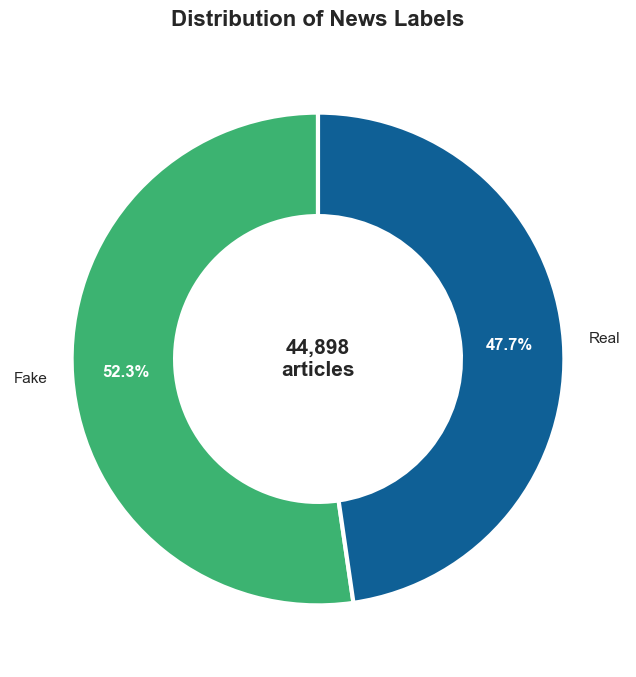

In [29]:
fig, ax = plt.subplots(figsize=(8, 8))

label_counts = eda_df['label_name'].value_counts().reindex(['Fake', 'Real'])

wedges, _, autotexts = ax.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=PRIMARY_COLORS,
    startangle=90,
    pctdistance=0.78,
    wedgeprops={'width': 0.42, 'edgecolor': 'white', 'linewidth': 3}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.text(0, 0, f"{len(eda_df):,}\narticles", ha='center', va='center', fontsize=15, fontweight='bold')
ax.set_title('Distribution of News Labels', fontsize=16, fontweight='bold', pad=18)
ax.set_aspect('equal')
plt.show()


### Count of Fake vs Real News

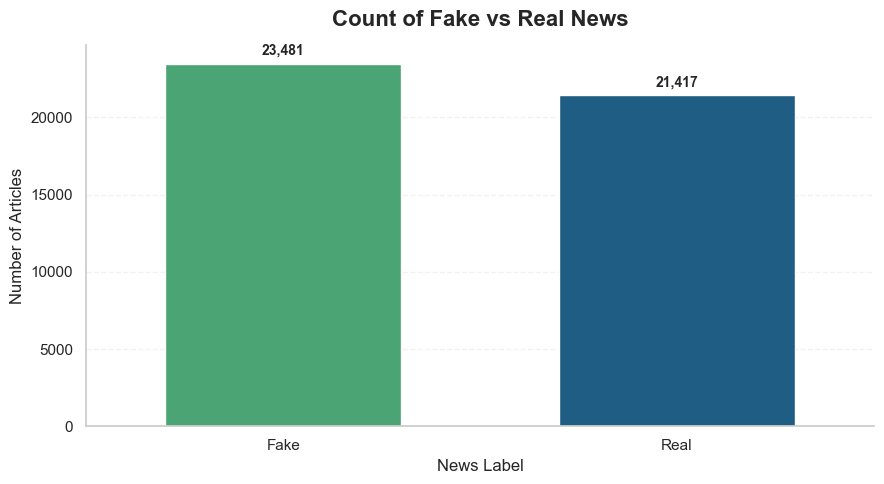

In [30]:
label_counts_df = label_counts.reset_index()
label_counts_df.columns = ['Label', 'Count']

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=label_counts_df, x='Label', y='Count', palette=PRIMARY_COLORS, width=0.6, ax=ax)
style_axes(ax, 'Count of Fake vs Real News', 'News Label', 'Number of Articles')
annotate_bars(ax)
plt.tight_layout()
plt.show()


The class distribution is approximately balanced, which is suitable for reliable model training and evaluation.

### Subject Distribution

Analyze how articles are distributed across subject categories to identify topical concentration and potential bias.

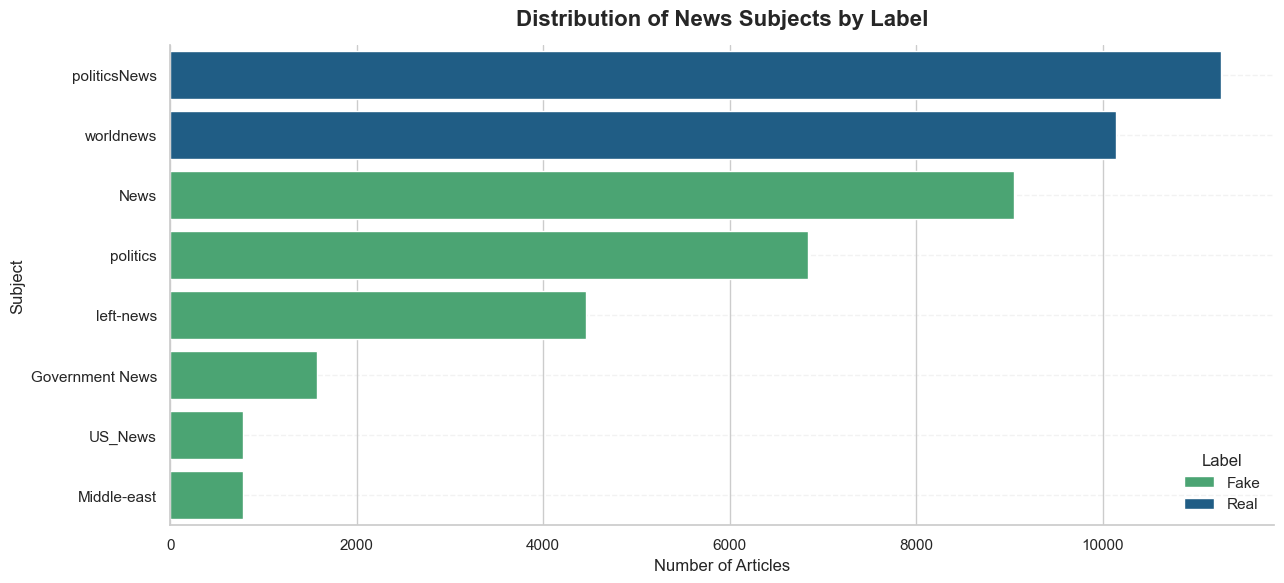

In [31]:
subject_order = eda_df['subject'].value_counts().index

fig, ax = plt.subplots(figsize=(13, 6))
sns.countplot(
    data=eda_df,
    y='subject',
    hue='label_name',
    order=subject_order,
    palette=PRIMARY_COLORS,
    ax=ax
)
style_axes(ax, 'Distribution of News Subjects by Label', 'Number of Articles', 'Subject')
ax.legend(title='Label', frameon=False)
plt.tight_layout()
plt.show()


### Subject Share Within Each Label
Compare which topics dominate fake and real articles after normalizing within each class.

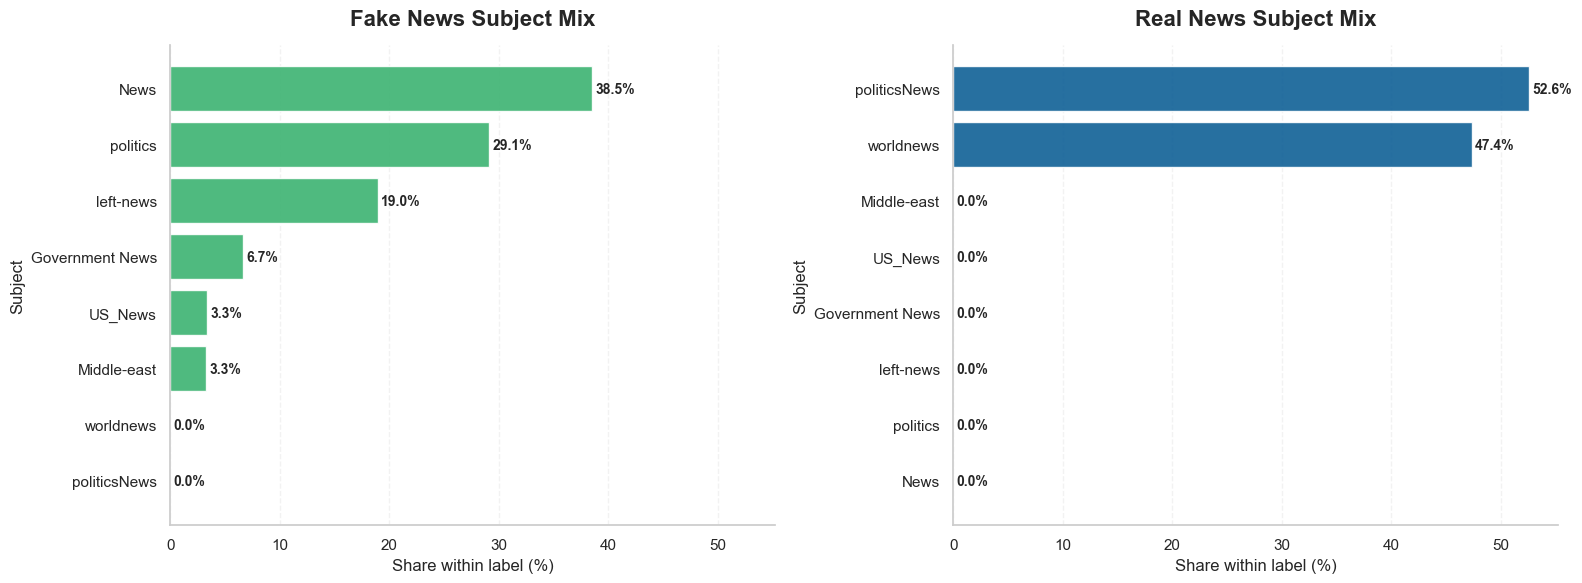

In [32]:
subject_share = (
    pd.crosstab(eda_df['subject'], eda_df['label_name'], normalize='columns')
    .mul(100)
    .reindex(subject_order)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for ax, label_name, color in zip(axes, ['Fake', 'Real'], PRIMARY_COLORS):
    share_data = subject_share[label_name].sort_values()
    ax.barh(share_data.index, share_data.values, color=color, alpha=0.9)
    style_axes(ax, f'{label_name} News Subject Mix', 'Share within label (%)', 'Subject')
    ax.grid(axis='x', linestyle='--', alpha=0.25)
    ax.grid(axis='y', visible=False)
    for idx, value in enumerate(share_data.values):
        ax.text(value + 0.3, idx, f'{value:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### Text Length Analysis

Compare text-length distributions between fake and real articles to understand writing-pattern differences.

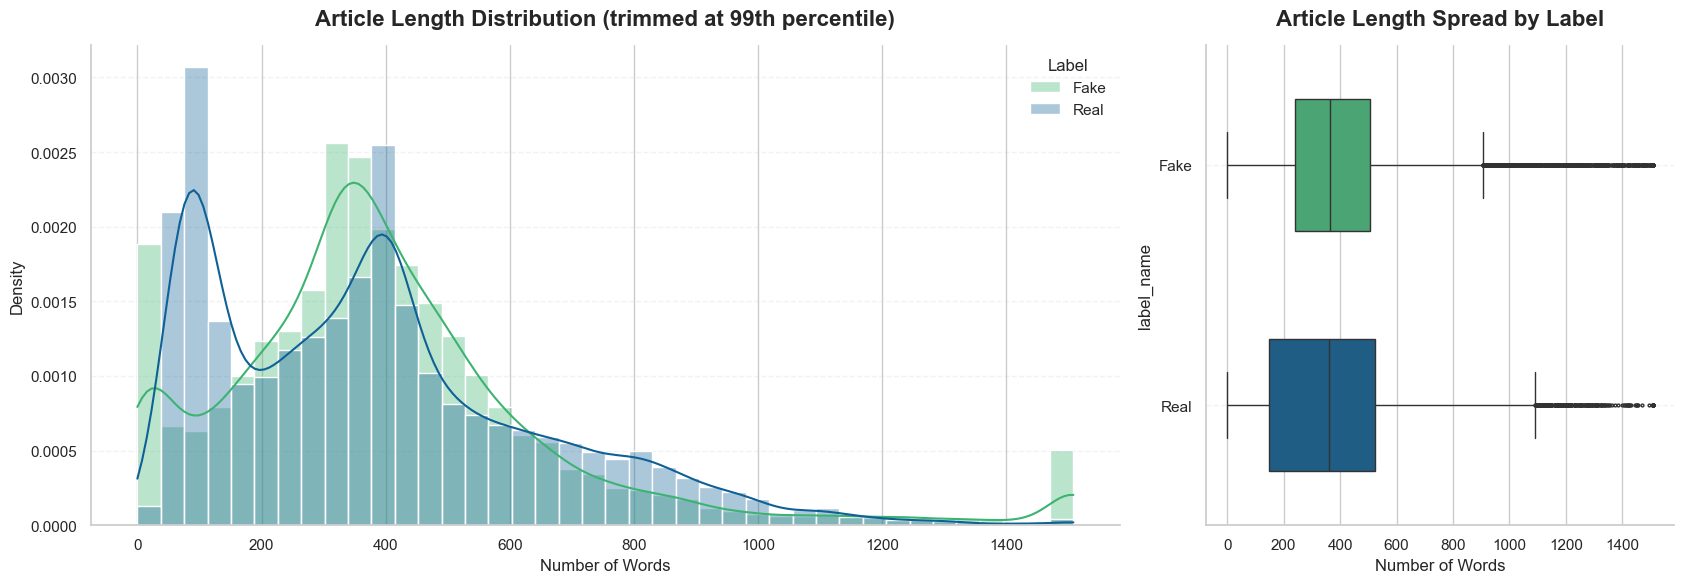

In [33]:
length_cap = eda_df['text_length'].quantile(0.99)
length_plot_df = eda_df.assign(text_length_capped=eda_df['text_length'].clip(upper=length_cap))

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [2.2, 1]})

for label_name, color in zip(['Fake', 'Real'], PRIMARY_COLORS):
    sns.histplot(
        data=length_plot_df[length_plot_df['label_name'] == label_name],
        x='text_length_capped',
        bins=40,
        stat='density',
        kde=True,
        alpha=0.35,
        color=color,
        label=label_name,
        ax=axes[0]
    )

style_axes(
    axes[0],
    'Article Length Distribution (trimmed at 99th percentile)',
    'Number of Words',
    'Density'
)
axes[0].legend(title='Label', frameon=False)

sns.boxplot(
    data=length_plot_df,
    y='label_name',
    x='text_length_capped',
    palette=PRIMARY_COLORS,
    width=0.55,
    fliersize=2,
    ax=axes[1]
)
style_axes(axes[1], 'Article Length Spread by Label', 'Number of Words', '')

plt.tight_layout()
plt.show()


### Publishing Trend Over Time
Use the article dates to see how fake and real news volume changes across the available timeline.

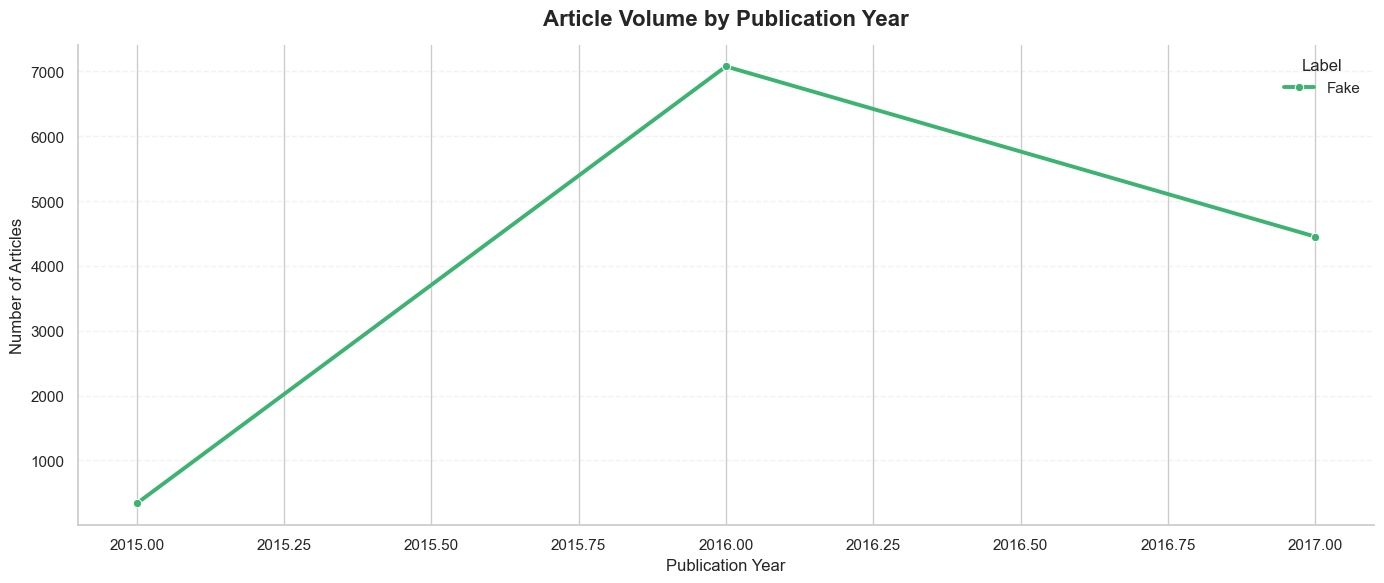

In [34]:
yearly_volume = (
    eda_df.dropna(subset=['published_year'])
    .groupby(['published_year', 'label_name'])
    .size()
    .reset_index(name='articles')
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=yearly_volume,
    x='published_year',
    y='articles',
    hue='label_name',
    style='label_name',
    markers=True,
    dashes=False,
    linewidth=2.8,
    palette=PRIMARY_COLORS,
    ax=ax
)
style_axes(ax, 'Article Volume by Publication Year', 'Publication Year', 'Number of Articles')
ax.legend(title='Label', frameon=False)
plt.tight_layout()
plt.show()


### Most Common Words

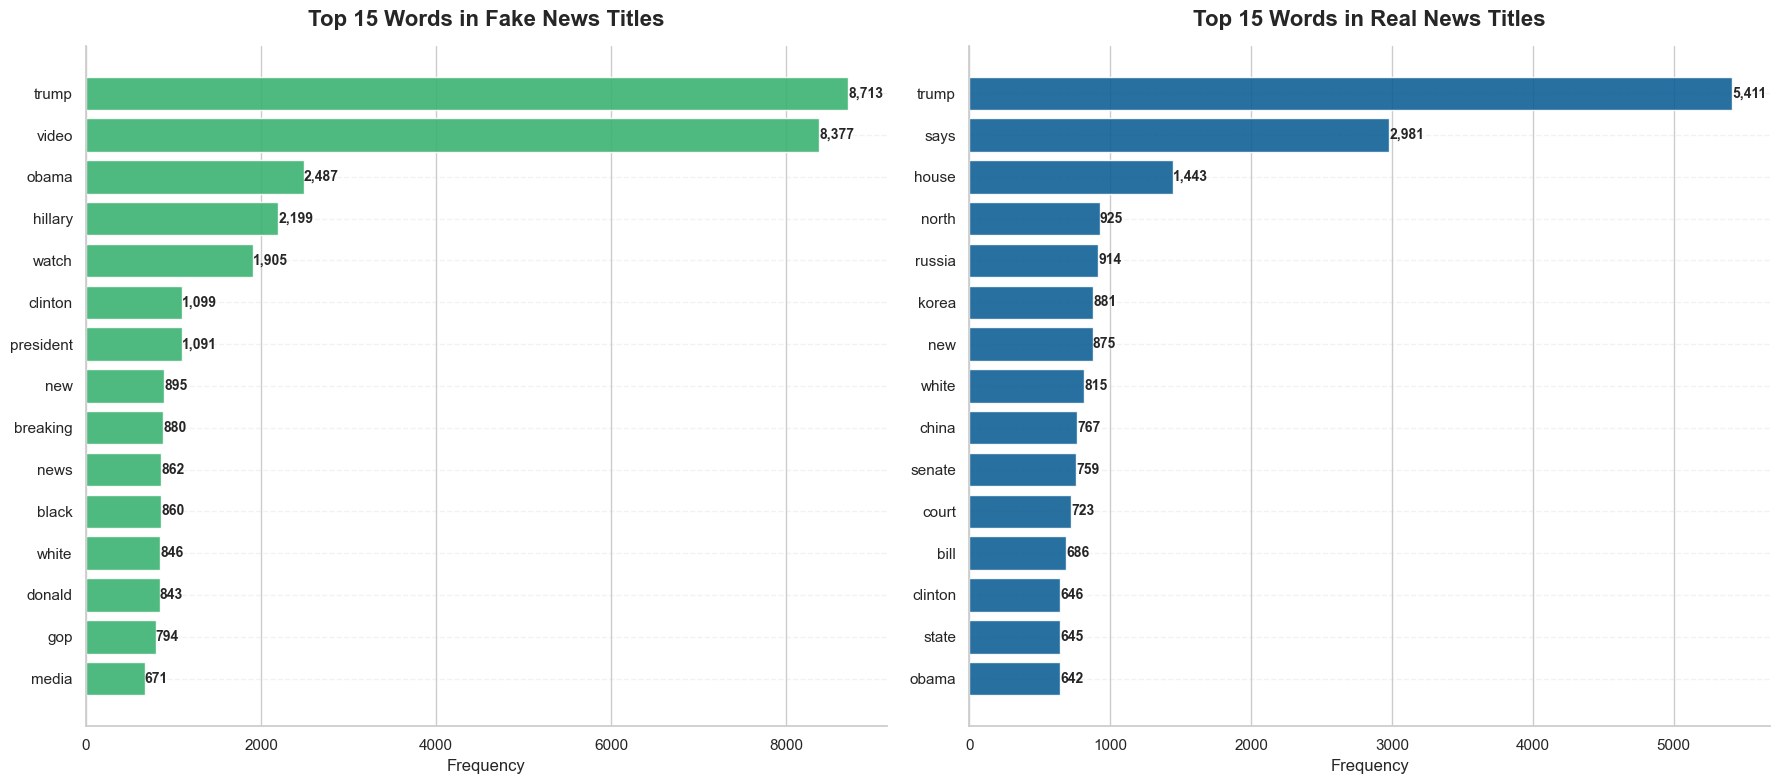

In [35]:
def count_words(text_series, min_length=3):
    combined_text = " ".join(text_series.dropna().astype(str))
    tokens = word_tokenize(combined_text.lower())
    tokens = [re.sub(r'[^a-z]', '', token) for token in tokens]
    tokens = [token for token in tokens if token and len(token) >= min_length and token not in EDA_STOPWORDS]
    return Counter(tokens)

def plot_top_words(ax, counter, color, title):
    top_words = pd.DataFrame(counter.most_common(15), columns=['word', 'count']).sort_values('count')
    ax.barh(top_words['word'], top_words['count'], color=color, alpha=0.9)
    style_axes(ax, title, 'Frequency', '')
    for idx, value in enumerate(top_words['count']):
        ax.text(value + 1, idx, f'{value:,}', va='center', fontsize=10, fontweight='bold')

fake_word_counts = count_words(eda_df.loc[eda_df['label_name'] == 'Fake', 'title'])
real_word_counts = count_words(eda_df.loc[eda_df['label_name'] == 'Real', 'title'])

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=False)
plot_top_words(axes[0], fake_word_counts, FAKE_COLOR, 'Top 15 Words in Fake News Titles')
plot_top_words(axes[1], real_word_counts, REAL_COLOR, 'Top 15 Words in Real News Titles')
plt.tight_layout()
plt.show()


### Word Clouds by Label
Use the same green and blue palette to highlight the dominant title vocabulary for fake and real news.

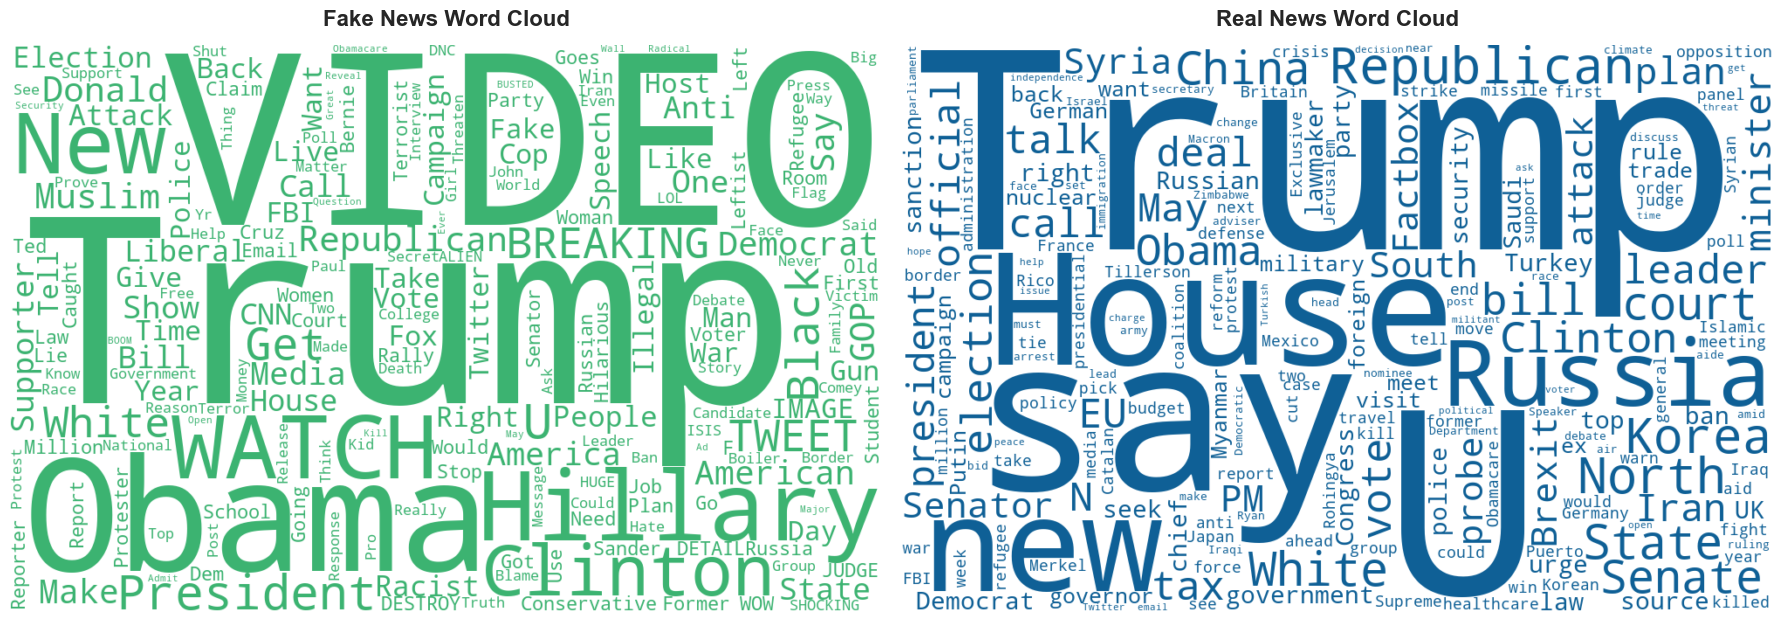

In [36]:
fake_text = " ".join(eda_df.loc[eda_df['label_name'] == 'Fake', 'title'].dropna().astype(str))
real_text = " ".join(eda_df.loc[eda_df['label_name'] == 'Real', 'title'].dropna().astype(str))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(build_wordcloud(fake_text, FAKE_COLOR), interpolation='bilinear')
axes[0].set_title('Fake News Word Cloud', fontsize=16, fontweight='bold', pad=14)
axes[0].axis('off')

axes[1].imshow(build_wordcloud(real_text, REAL_COLOR), interpolation='bilinear')
axes[1].set_title('Real News Word Cloud', fontsize=16, fontweight='bold', pad=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


## Pipeline Stage 03: Data Cleaning
This stage performs the structural cleaning requested in the model-building pipeline before any NLP preprocessing is applied.

### Step 03.1 Audit the Raw Modeling Columns
Inspect the fields that will feed the classification pipeline and quantify structural issues before cleaning.

In [37]:
modeling_columns = ['title', 'text', 'subject', 'date', 'label']
structural_audit = pd.DataFrame({
    'missing_values': df[modeling_columns].isna().sum(),
    'missing_%': (df[modeling_columns].isna().mean() * 100).round(2),
    'unique_values': df[modeling_columns].nunique()
})

duplicate_articles = df.duplicated(subset=['title', 'text', 'label']).sum()

display(structural_audit)
print(f"Duplicate articles based on title + text + label: {duplicate_articles:,}")
print(f"Initial dataset shape for modeling: {df[modeling_columns].shape}")

,missing_values,missing_%,unique_values
title,0,0.0,38729
text,0,0.0,38646
subject,0,0.0,8
date,0,0.0,2397
label,0,0.0,2


Duplicate articles based on title + text + label: 5,793
Initial dataset shape for modeling: (44898, 5)


### Step 03.2 Apply Structural Data Cleaning
Keep the required columns, standardize types, assemble a raw-text field, remove unusable rows, and drop duplicates.

In [38]:
model_df = df[modeling_columns].copy()

model_df['title'] = model_df['title'].fillna('').astype(str).str.strip()
model_df['text'] = model_df['text'].fillna('').astype(str).str.strip()
model_df['subject'] = model_df['subject'].astype(str).str.strip()
model_df['date'] = model_df['date'].astype(str).str.strip()

model_df['raw_text'] = (
    model_df['title'].fillna('') + ' ' + model_df['text'].fillna('')
).str.replace(r'\s+', ' ', regex=True).str.strip()

rows_before_cleaning = len(model_df)
model_df = model_df.replace({'raw_text': {'': np.nan}})
model_df = model_df.dropna(subset=['raw_text', 'subject', 'date', 'label']).copy()
model_df = model_df.drop_duplicates(subset=['title', 'text', 'label']).reset_index(drop=True)
rows_after_cleaning = len(model_df)

print(f"Rows removed during structural cleaning: {rows_before_cleaning - rows_after_cleaning:,}")
print(f"Dataset shape after data cleaning: {model_df.shape}")
display(model_df[['title', 'subject', 'date', 'label', 'raw_text']].head(3))

Rows removed during structural cleaning: 5,795
Dataset shape after data cleaning: (39103, 6)


,title,subject,date,label,raw_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...


### Step 03.3 Verify the Cleaned Dataset
Confirm the cleaned data quality before entering the detailed text-preprocessing pipeline.

In [39]:
cleaning_summary = pd.DataFrame({
    'rows': [len(model_df)],
    'columns': [model_df.shape[1]],
    'empty_raw_text': [model_df['raw_text'].eq('').sum()],
    'missing_labels': [model_df['label'].isna().sum()],
    'class_balance_fake': [(model_df['label'] == 0).sum()],
    'class_balance_real': [(model_df['label'] == 1).sum()]
})

display(cleaning_summary)
display(model_df[['label', 'subject']].describe(include='all'))

,rows,columns,empty_raw_text,missing_labels,class_balance_fake,class_balance_real
0,39103,6,0,0,17907,21196


,label,subject
count,39103.000000,39103
unique,NaN,8
top,NaN,politicsNews
freq,NaN,11211
mean,0.542056,NaN
std,0.498235,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,1.000000,NaN
75%,1.000000,NaN


## Pipeline Stage 04: Text Preprocessing
This stage follows the detailed preprocessing pipeline requested by the professor:

1. Text normalization
2. Text cleaning
3. Tokenization
4. Stopword removal
5. Lemmatization with POS tagging
6. Final cleaned text generation for vectorization

### Step 04.0 Define Preprocessing Resources and Helper Functions
Build reusable helpers so each sub-step of the NLP pipeline is explicit, inspectable, and reproducible.

In [40]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

CONTRACTION_MAP = {
    "can't": 'cannot',
    "won't": 'will not',
    "n't": ' not',
    "'re": ' are',
    "'s": ' is',
    "'d": ' would',
    "'ll": ' will',
    "'t": ' not',
    "'ve": ' have',
    "'m": ' am'
}

ABBREVIATION_MAP = {
    'u.s.': 'us',
    'u.k.': 'uk',
    'govt': 'government',
    'w/': 'with',
    'w/o': 'without',
    'dept': 'department',
    'info': 'information'
}

def replace_dictionary_terms(text, mapping):
    for source, target in mapping.items():
        text = re.sub(rf'\b{re.escape(source)}\b', target, text)
    return text

def normalize_text(text):
    text = str(text)
    text = emoji.demojize(text, delimiters=(' ', ' '))
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = text.lower()
    text = replace_dictionary_terms(text, CONTRACTION_MAP)
    text = replace_dictionary_terms(text, ABBREVIATION_MAP)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text_content(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&\w+;', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(rf'[{re.escape(string.punctuation)}]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_text(text):
    return [token for token in word_tokenize(text) if token.isalpha()]

def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words and len(token) > 2]

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    if tag.startswith('V'):
        return wordnet.VERB
    if tag.startswith('N'):
        return wordnet.NOUN
    if tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

def lemmatize_with_pos(tokens):
    tagged_tokens = pos_tag(tokens)
    return [lemmatizer.lemmatize(token, get_wordnet_pos(tag)) for token, tag in tagged_tokens]

def preprocess_pipeline(text):
    normalized = normalize_text(text)
    cleaned = clean_text_content(normalized)
    tokens = tokenize_text(cleaned)
    filtered_tokens = remove_stopwords(tokens)
    lemmas = lemmatize_with_pos(filtered_tokens)
    return ' '.join(lemmas)

### Step 04.1 Text Normalization
Normalize case, whitespace, contractions, abbreviations, and emojis before deeper cleaning.

In [41]:
tqdm.pandas(desc='Text normalization')
model_df['normalized_text'] = model_df['raw_text'].progress_apply(normalize_text)

display(
    model_df[['raw_text', 'normalized_text']]
    .head(3)
    .assign(
        raw_text=lambda frame: frame['raw_text'].str.slice(0, 180) + '...',
        normalized_text=lambda frame: frame['normalized_text'].str.slice(0, 180) + '...'
    )
)

Text normalization: 100%|██████████| 39103/39103 [03:09<00:00, 206.39it/s]


,raw_text,normalized_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls out 9th circuit court: committ...
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon from national securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u.s. to lift jones act shi...


### Step 04.2 Text Cleaning
Remove URLs, HTML/XML tags, punctuation, digits, and other non-informative artifacts.

In [42]:
tqdm.pandas(desc='Text cleaning')
model_df['clean_text'] = model_df['normalized_text'].progress_apply(clean_text_content)

display(
    model_df[['normalized_text', 'clean_text']]
    .head(3)
    .assign(
        normalized_text=lambda frame: frame['normalized_text'].str.slice(0, 180) + '...',
        clean_text=lambda frame: frame['clean_text'].str.slice(0, 180) + '...'
    )
)

Text cleaning: 100%|██████████| 39103/39103 [00:11<00:00, 3513.49it/s]


,normalized_text,clean_text
0,ben stein calls out 9th circuit court: committ...,ben stein calls out th circuit court committed...
1,trump drops steve bannon from national securit...,trump drops steve bannon from national securit...
2,puerto rico expects u.s. to lift jones act shi...,puerto rico expects u s to lift jones act ship...


### Step 04.3 Tokenization
Split the cleaned text into individual lexical tokens for token-level processing.

In [43]:
tqdm.pandas(desc='Tokenization')
model_df['tokens'] = model_df['clean_text'].progress_apply(tokenize_text)
model_df['token_count'] = model_df['tokens'].str.len()

display(model_df[['clean_text', 'tokens', 'token_count']].head(3))

Tokenization: 100%|██████████| 39103/39103 [00:58<00:00, 674.07it/s]


,clean_text,tokens,token_count
0,ben stein calls out th circuit court committed...,"[ben, stein, calls, out, th, circuit, court, c...",186
1,trump drops steve bannon from national securit...,"[trump, drops, steve, bannon, from, national, ...",791
2,puerto rico expects u s to lift jones act ship...,"[puerto, rico, expects, u, s, to, lift, jones,...",321


### Step 04.4 Remove Stopwords
Filter common function words so the downstream model focuses on the more discriminative tokens.

In [44]:
tqdm.pandas(desc='Stopword removal')
model_df['tokens_no_stopwords'] = model_df['tokens'].progress_apply(remove_stopwords)
model_df['filtered_token_count'] = model_df['tokens_no_stopwords'].str.len()

display(model_df[['tokens', 'tokens_no_stopwords', 'filtered_token_count']].head(3))

Stopword removal: 100%|██████████| 39103/39103 [00:02<00:00, 14443.63it/s]


,tokens,tokens_no_stopwords,filtered_token_count
0,"[ben, stein, calls, out, th, circuit, court, c...","[ben, stein, calls, circuit, court, committed,...",105
1,"[trump, drops, steve, bannon, from, national, ...","[trump, drops, steve, bannon, national, securi...",469
2,"[puerto, rico, expects, u, s, to, lift, jones,...","[puerto, rico, expects, lift, jones, act, ship...",181


### Step 04.5 Lemmatization with POS Tagging
Apply part-of-speech-aware lemmatization so tokens are reduced to linguistically meaningful base forms.

In [ ]:
tqdm.pandas(desc='POS-aware lemmatization')
model_df['lemmatized_tokens'] = model_df['tokens_no_stopwords'].progress_apply(lemmatize_with_pos)
model_df['lemma_count'] = model_df['lemmatized_tokens'].str.len()

display(model_df[['tokens_no_stopwords', 'lemmatized_tokens', 'lemma_count']].head(3))

POS-aware lemmatization:  74%|███████▍  | 29104/39103 [08:07<02:43, 61.33it/s]

### Step 04.6 Build the Final Modeling Text
Join the lemmatized tokens into the final text column used by the vectorizer and classifiers.

In [ ]:
model_df['cleaned_text'] = model_df['lemmatized_tokens'].apply(lambda tokens: ' '.join(tokens))
model_df = model_df[model_df['cleaned_text'].str.strip().ne('')].reset_index(drop=True)

preprocessing_preview = (
    model_df[
        ['raw_text', 'normalized_text', 'clean_text', 'tokens', 'tokens_no_stopwords', 'lemmatized_tokens', 'cleaned_text']
    ]
    .head(3)
    .copy()
)
preprocessing_preview['raw_text'] = preprocessing_preview['raw_text'].str.slice(0, 140) + '...'
preprocessing_preview['normalized_text'] = preprocessing_preview['normalized_text'].str.slice(0, 140) + '...'
preprocessing_preview['clean_text'] = preprocessing_preview['clean_text'].str.slice(0, 140) + '...'
preprocessing_preview['cleaned_text'] = preprocessing_preview['cleaned_text'].str.slice(0, 140) + '...'

print(f"Final modeling dataset shape after preprocessing: {model_df.shape}")
display(preprocessing_preview)

## Pipeline Stage 05: Data Split
Split the fully cleaned and preprocessed data into training and testing sets before vectorization and model fitting.

### Step 05.1 Stratified Train/Test Split
Use the professor's train > test principle while preserving the class ratio in both partitions.

In [ ]:
X = model_df['cleaned_text']
y = model_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

split_summary = pd.DataFrame({
    'split': ['Train', 'Test'],
    'rows': [len(X_train), len(X_test)],
    'fake_ratio': [(y_train == 0).mean().round(4), (y_test == 0).mean().round(4)],
    'real_ratio': [(y_train == 1).mean().round(4), (y_test == 1).mean().round(4)]
})

display(split_summary)

## Pipeline Stage 06: Word Vector Representation
The professor's word-vector stage is implemented with TF-IDF so the cleaned news text becomes machine-readable numerical features for the classical classifiers.

### Step 06.1 Fit the TF-IDF Vectorizer
Learn the vocabulary from the training split only, then transform both train and test sets into sparse document vectors.

In [ ]:
vectorizer_config = {
    'max_features': 10000,
    'ngram_range': (1, 2),
    'min_df': 5,
    'max_df': 0.85,
    'sublinear_tf': True
}

tfidf_vectorizer = TfidfVectorizer(**vectorizer_config)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

feature_names = tfidf_vectorizer.get_feature_names_out()
vector_summary = pd.DataFrame({
    'train_rows': [X_train_tfidf.shape[0]],
    'test_rows': [X_test_tfidf.shape[0]],
    'features': [X_train_tfidf.shape[1]],
    'sample_terms': [', '.join(feature_names[:12])]
})

display(vector_summary)

## Pipeline Stage 07: ML Algorithm Building
Following the high-level pipeline, baseline models are first built with literature-guided classical algorithms. For runtime efficiency, this notebook reuses the TF-IDF matrices created in Stage 06 during benchmarking, then packages the fitted vectorizer and classifier together when saving deployment artifacts.


### Step 07.1 Define the Baseline Algorithms
The baseline shortlist uses four standard text-classification models commonly reported in fake-news detection studies: Logistic Regression, Multinomial Naive Bayes, Linear SVM, and Random Forest.

In [ ]:
MODEL_SPECS = {
    'Logistic Regression': {
        'slug': 'logistic_regression',
        'builder': lambda: LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
    },
    'Naive Bayes': {
        'slug': 'naive_bayes',
        'builder': lambda: MultinomialNB()
    },
    'Linear SVM': {
        'slug': 'linear_svm',
        'builder': lambda: LinearSVC(random_state=42, dual=False, max_iter=5000)
    },
    'Random Forest': {
        'slug': 'random_forest',
        'builder': lambda: RandomForestClassifier(
            n_estimators=120,
            random_state=42,
            class_weight='balanced',
            max_depth=30,
            min_samples_leaf=2,
            n_jobs=1
        )
    }
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
repeated_cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

def create_prefit_pipeline(fitted_classifier):
    return Pipeline([
        ('tfidf', tfidf_vectorizer),
        ('classifier', fitted_classifier)
    ])

def get_scores_and_probabilities(model, X_input):
    predictions = model.predict(X_input)
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(X_input)[:, 1]
    elif hasattr(model, 'decision_function'):
        decision_scores = model.decision_function(X_input)
        probabilities = 1 / (1 + np.exp(-decision_scores))
    else:
        probabilities = predictions.astype(float)
    return predictions, probabilities

def evaluate_model(model, X_eval, y_eval):
    predictions, probabilities = get_scores_and_probabilities(model, X_eval)
    return {
        'accuracy': accuracy_score(y_eval, predictions),
        'precision': precision_score(y_eval, predictions),
        'recall': recall_score(y_eval, predictions),
        'f1': f1_score(y_eval, predictions),
        'predictions': predictions,
        'probabilities': probabilities,
        'classification_report': classification_report(y_eval, predictions)
    }

artifact_dir = Path('Models')
artifact_dir.mkdir(exist_ok=True)

def save_model_artifacts(slug, fitted_classifier):
    pipeline_artifact = create_prefit_pipeline(fitted_classifier)
    joblib.dump(pipeline_artifact, artifact_dir / f'{slug}_pipeline.pkl')
    joblib.dump(fitted_classifier, artifact_dir / f'{slug}_model.pkl')
    return pipeline_artifact


### Step 07.2 Train and Benchmark the Baseline Models
Each baseline model is trained on the training split, evaluated on the held-out test split, and saved as both a classifier artifact and a full text pipeline artifact.

In [ ]:
baseline_results = {}

for model_name, spec in MODEL_SPECS.items():
    print(f"\n{'=' * 70}")
    print(f"BASELINE TRAINING: {model_name}")
    print(f"{'=' * 70}")

    classifier = spec['builder']()
    cv_scores = cross_val_score(classifier, X_train_tfidf, y_train, cv=cv_strategy, scoring='f1', n_jobs=1)
    classifier.fit(X_train_tfidf, y_train)

    evaluation = evaluate_model(classifier, X_test_tfidf, y_test)
    saved_pipeline = save_model_artifacts(spec['slug'], classifier)

    baseline_results[model_name] = {
        'stage': 'baseline',
        'model': classifier,
        'pipeline': saved_pipeline,
        'accuracy': evaluation['accuracy'],
        'precision': evaluation['precision'],
        'recall': evaluation['recall'],
        'f1': evaluation['f1'],
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': evaluation['predictions'],
        'probabilities': evaluation['probabilities'],
        'classification_report': evaluation['classification_report'],
        'best_params': 'Default hyperparameters',
        'search_method': 'Baseline'
    }

    print(f"Accuracy : {evaluation['accuracy']:.4f}")
    print(f"Precision: {evaluation['precision']:.4f}")
    print(f"Recall   : {evaluation['recall']:.4f}")
    print(f"F1 Score : {evaluation['f1']:.4f}")
    print(f"CV F1    : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


### Step 07.3 Compare the Baseline Models
Summarize the initial performance before the hyperparameter-tuning stage.

In [ ]:
baseline_comparison = (
    pd.DataFrame([
        {
            'Model': name,
            'Accuracy': result['accuracy'],
            'Precision': result['precision'],
            'Recall': result['recall'],
            'F1 Score': result['f1'],
            'CV F1 Mean': result['cv_mean'],
            'CV F1 Std': result['cv_std']
        }
        for name, result in baseline_results.items()
    ])
    .sort_values('F1 Score', ascending=False)
    .reset_index(drop=True)
)

display(baseline_comparison.round(4))

### Step 07.4 Robust Cross-Validation Diagnostics
Use stronger validation patterns by comparing Stratified K-Fold and repeated stratified cross-validation on the strongest baseline candidates.

In [ ]:
top_baseline_models = baseline_comparison.head(2)['Model'].tolist()
robust_cv_records = []

for model_name in top_baseline_models:
    classifier = MODEL_SPECS[model_name]['builder']()

    stratified_scores = cross_val_score(
        classifier,
        X_train_tfidf,
        y_train,
        cv=cv_strategy,
        scoring='f1',
        n_jobs=1
    )
    repeated_scores = cross_val_score(
        classifier,
        X_train_tfidf,
        y_train,
        cv=repeated_cv_strategy,
        scoring='f1',
        n_jobs=1
    )

    robust_cv_records.append({
        'Model': model_name,
        'Stratified CV Mean': stratified_scores.mean(),
        'Stratified CV Std': stratified_scores.std(),
        'Repeated Stratified CV Mean': repeated_scores.mean(),
        'Repeated Stratified CV Std': repeated_scores.std(),
        'Best Baseline Test F1': baseline_results[model_name]['f1']
    })

robust_cv_df = pd.DataFrame(robust_cv_records).sort_values('Repeated Stratified CV Mean', ascending=False)
display(robust_cv_df.round(4))


## Pipeline Stage 08: Hyperparameter Tuning
The professor's tuning block is implemented with GridSearchCV for the shortlisted models and a RandomizedSearchCV refinement, using F1 score as the selection criterion.


### Step 08.1 Define the Tuning Search Space
Shortlist the most competitive sparse-text classifiers and specify compact, assignment-friendly search grids.

In [ ]:
TUNING_CONFIGS = {
    'Logistic Regression': {
        'param_grid': {
            'C': [0.5, 1.0, 3.0],
            'class_weight': [None, 'balanced'],
            'solver': ['liblinear']
        }
    },
    'Naive Bayes': {
        'param_grid': {
            'alpha': [0.1, 0.5, 1.0, 2.0]
        }
    },
    'Linear SVM': {
        'param_grid': {
            'C': [0.5, 1.0, 3.0],
            'class_weight': [None, 'balanced']
        }
    }
}


### Step 08.2 Run GridSearchCV on the Shortlisted Models
Tune each candidate on the training split only, then evaluate the tuned version on the untouched test split.

In [ ]:
tuned_results = {}

for model_name, tuning_config in TUNING_CONFIGS.items():
    print(f"\n{'=' * 70}")
    print(f"HYPERPARAMETER TUNING: {model_name}")
    print(f"{'=' * 70}")

    classifier = MODEL_SPECS[model_name]['builder']()

    grid_search = GridSearchCV(
        estimator=classifier,
        param_grid=tuning_config['param_grid'],
        scoring='f1',
        cv=cv_strategy,
        n_jobs=1,
        verbose=1
    )
    grid_search.fit(X_train_tfidf, y_train)

    best_classifier = grid_search.best_estimator_
    evaluation = evaluate_model(best_classifier, X_test_tfidf, y_test)
    saved_pipeline = save_model_artifacts(MODEL_SPECS[model_name]['slug'], best_classifier)

    tuned_results[model_name] = {
        'stage': 'tuned',
        'model': best_classifier,
        'pipeline': saved_pipeline,
        'accuracy': evaluation['accuracy'],
        'precision': evaluation['precision'],
        'recall': evaluation['recall'],
        'f1': evaluation['f1'],
        'cv_mean': grid_search.best_score_,
        'cv_std': np.nan,
        'predictions': evaluation['predictions'],
        'probabilities': evaluation['probabilities'],
        'classification_report': evaluation['classification_report'],
        'best_params': grid_search.best_params_,
        'search_method': 'GridSearchCV'
    }

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Accuracy       : {evaluation['accuracy']:.4f}")
    print(f"Precision      : {evaluation['precision']:.4f}")
    print(f"Recall         : {evaluation['recall']:.4f}")
    print(f"F1 Score       : {evaluation['f1']:.4f}")
    print(f"Best CV F1     : {grid_search.best_score_:.4f}")


### Step 08.3 RandomizedSearchCV Refinement
Perform a secondary randomized search on Linear SVM and keep it only if it improves the validation score over the grid-search version.

In [ ]:
random_search_candidate = 'Linear SVM'
randomized_search = RandomizedSearchCV(
    estimator=MODEL_SPECS[random_search_candidate]['builder'](),
    param_distributions={
        'C': np.linspace(0.25, 4.0, 16),
        'class_weight': [None, 'balanced']
    },
    n_iter=10,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=1,
    random_state=42,
    verbose=1
)
randomized_search.fit(X_train_tfidf, y_train)

randomized_classifier = randomized_search.best_estimator_
randomized_evaluation = evaluate_model(randomized_classifier, X_test_tfidf, y_test)
randomized_pipeline = create_prefit_pipeline(randomized_classifier)
randomized_result = {
    'stage': 'tuned',
    'model': randomized_classifier,
    'pipeline': randomized_pipeline,
    'accuracy': randomized_evaluation['accuracy'],
    'precision': randomized_evaluation['precision'],
    'recall': randomized_evaluation['recall'],
    'f1': randomized_evaluation['f1'],
    'cv_mean': randomized_search.best_score_,
    'cv_std': np.nan,
    'predictions': randomized_evaluation['predictions'],
    'probabilities': randomized_evaluation['probabilities'],
    'classification_report': randomized_evaluation['classification_report'],
    'best_params': randomized_search.best_params_,
    'search_method': 'RandomizedSearchCV'
}

grid_reference = tuned_results[random_search_candidate]
randomized_is_better = (
    randomized_result['cv_mean'] > grid_reference['cv_mean'] or
    (
        np.isclose(randomized_result['cv_mean'], grid_reference['cv_mean'])
        and randomized_result['f1'] > grid_reference['f1']
    )
)

random_search_summary = pd.DataFrame([
    {
        'Search Method': grid_reference['search_method'],
        'Best CV F1': grid_reference['cv_mean'],
        'Test F1': grid_reference['f1'],
        'Best Parameters': str(grid_reference['best_params'])
    },
    {
        'Search Method': randomized_result['search_method'],
        'Best CV F1': randomized_result['cv_mean'],
        'Test F1': randomized_result['f1'],
        'Best Parameters': str(randomized_result['best_params'])
    }
])
display(random_search_summary.round(4))

if randomized_is_better:
    tuned_results[random_search_candidate] = randomized_result
    save_model_artifacts(MODEL_SPECS[random_search_candidate]['slug'], randomized_classifier)
    print('RandomizedSearchCV improved the Linear SVM candidate, so the tuned result was updated.')
else:
    print('GridSearchCV remains the stronger Linear SVM result, so the tuned result was kept unchanged.')


## Pipeline Stage 09: Tuned Model Selection
Select the final tuned model using cross-validated F1 score, then save the deployment artifacts in the Models folder.


### Step 09.1 Compare Tuned Candidates and Pick the Final Model
The final choice is based on the strongest validation performance, with the held-out test metrics reported alongside it.

In [ ]:
tuned_comparison = (
    pd.DataFrame([
        {
            'Model': name,
            'Accuracy': result['accuracy'],
            'Precision': result['precision'],
            'Recall': result['recall'],
            'F1 Score': result['f1'],
            'Best CV F1': result['cv_mean'],
            'Search Method': result.get('search_method', 'GridSearchCV'),
            'Best Parameters': str(result['best_params'])
        }
        for name, result in tuned_results.items()
    ])
    .sort_values('Best CV F1', ascending=False)
    .reset_index(drop=True)
)

display(tuned_comparison.round(4))

best_model_name = tuned_comparison.loc[0, 'Model']
best_model_classifier = tuned_results[best_model_name]['model']
best_model_pipeline = create_prefit_pipeline(best_model_classifier)
best_model_slug = MODEL_SPECS[best_model_name]['slug']

print(f"Selected final tuned model: {best_model_name}")
print(f"Validation selection score (Best CV F1): {tuned_results[best_model_name]['cv_mean']:.4f}")
print(f"Test F1 of selected model: {tuned_results[best_model_name]['f1']:.4f}")

final_results = baseline_results.copy()
final_results.update(tuned_results)

benchmark_results = {
    name: {
        'accuracy': result['accuracy'],
        'precision': result['precision'],
        'recall': result['recall'],
        'f1': result['f1'],
        'cv_mean': result['cv_mean'],
        'cv_std': result['cv_std'],
        'stage': result['stage'],
        'best_params': result['best_params'],
        'search_method': result.get('search_method', result['stage'])
    }
    for name, result in final_results.items()
}

best_model_metadata = {
    'best_model_name': best_model_name,
    'best_model_slug': best_model_slug,
    'vectorizer_config': vectorizer_config
}

joblib.dump(tfidf_vectorizer, artifact_dir / 'tfidf_vectorizer.pkl')
joblib.dump(best_model_pipeline, artifact_dir / 'best_model_pipeline.pkl')
joblib.dump(best_model_classifier, artifact_dir / 'best_model_estimator.pkl')

for metrics_file in ['benchmark_results.pkl', 'model_metrics.pkl', 'model_RF_results.pkl', 'model_LSVM_results.pkl']:
    with open(artifact_dir / metrics_file, 'wb') as handle:
        pickle.dump(benchmark_results, handle)

with open(artifact_dir / 'best_model_metadata.pkl', 'wb') as handle:
    pickle.dump(best_model_metadata, handle)

display(pd.DataFrame(best_model_metadata.items(), columns=['Item', 'Value']))


## Pipeline Stage 10: Evaluation
Evaluate the selected tuned model on the held-out test set using the same metrics highlighted in the professor's model-building pipeline.

### Step 10.1 Visual Evaluation of the Final Tuned Model
Generate a confusion matrix, ROC curve, and precision-recall curve for the selected tuned model.

In [ ]:
selected_result = tuned_results[best_model_name]
y_pred = selected_result['predictions']
y_score = selected_result['probabilities']

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Fake', 'Real'],
    cmap='Blues',
    colorbar=False,
    ax=axes[0]
)
axes[0].set_title(f'{best_model_name} Confusion Matrix', fontsize=14, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color=REAL_COLOR, linewidth=2.5, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(frameon=False)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score)
pr_auc = auc(recall_vals, precision_vals)
axes[2].plot(recall_vals, precision_vals, color=FAKE_COLOR, linewidth=2.5, label=f'AUC = {pr_auc:.4f}')
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

print(selected_result['classification_report'])

### Step 10.2 Compare Baseline and Tuned Performance
Show how the tuned candidates compare against the original baselines using the same evaluation metrics.

In [ ]:
comparison_records = []

for stage_name, result_set in [('Baseline', baseline_results), ('Tuned', tuned_results)]:
    for model_name, result in result_set.items():
        comparison_records.append({
            'Stage': stage_name,
            'Model': model_name,
            'Accuracy': result['accuracy'],
            'Precision': result['precision'],
            'Recall': result['recall'],
            'F1 Score': result['f1']
        })

comparison_df = pd.DataFrame(comparison_records)
display(comparison_df.round(4))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=comparison_df,
    x='Model',
    y='F1 Score',
    hue='Stage',
    palette=PRIMARY_COLORS,
    ax=ax
)
style_axes(ax, 'Baseline vs Tuned Model F1 Scores', 'Model', 'F1 Score')
ax.legend(title='Stage', frameon=False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Pipeline Stage 11: Sample Prediction
Use the final preprocessing pipeline and the selected tuned classifier to perform end-to-end fake-news prediction on unseen text.

### Step 11.1 Define the End-to-End Prediction Function
The function mirrors the exact notebook pipeline: preprocess raw text, vectorize it through the fitted model pipeline, then produce the prediction and confidence score.

In [ ]:
def predict_news(text, trained_pipeline):
    cleaned_text = preprocess_pipeline(text)

    prediction = trained_pipeline.predict([cleaned_text])[0]
    if hasattr(trained_pipeline, 'predict_proba'):
        probabilities = trained_pipeline.predict_proba([cleaned_text])[0]
    elif hasattr(trained_pipeline, 'decision_function'):
        decision_score = float(trained_pipeline.decision_function([cleaned_text])[0])
        real_probability = 1 / (1 + np.exp(-decision_score))
        probabilities = np.array([1 - real_probability, real_probability])
    else:
        probabilities = np.array([1.0, 0.0]) if prediction == 0 else np.array([0.0, 1.0])

    label = 'Fake News' if prediction == 0 else 'Real News'
    confidence = probabilities[0] if prediction == 0 else probabilities[1]

    return {
        'label': label,
        'confidence': float(confidence),
        'probabilities': probabilities,
        'cleaned_text': cleaned_text
    }

example_text = """BREAKING: Government secretly installed mind-control devices in vaccines, according to anonymous insiders who claim that every tower in the city is now activating the chips."""

sample_prediction = predict_news(example_text, best_model_pipeline)
print(f"Predicted label : {sample_prediction['label']}")
print(f"Confidence      : {sample_prediction['confidence']:.4f}")
print(f"Cleaned text    : {sample_prediction['cleaned_text'][:250]}...")